In [64]:
##import package
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

In [65]:
# helper function
def d_optimal_initialization(X, n_init=200):
    """
    D-Optimal Design: select points that maximize feature space coverage
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    n_samples = X_scaled.shape[0]
    selected = []
    remaining = set(range(n_samples))
    
    # Start with point furthest from origin
    norms = np.linalg.norm(X_scaled, axis=1)
    first_idx = np.argmax(norms)
    selected.append(first_idx)
    remaining.remove(first_idx)
    
    for i in range(n_init - 1):
        best_idx = None
        best_det = -np.inf
        
        X_selected = X_scaled[selected]
        
        # Sample 1000 candidates for efficiency
        candidates = list(remaining)
        if len(candidates) > 1000:
            candidates = np.random.choice(candidates, 1000, replace=False)
        
        for idx in candidates:
            X_candidate = np.vstack([X_selected, X_scaled[idx]])
            XtX = X_candidate.T @ X_candidate
            _, logdet = np.linalg.slogdet(XtX)
            
            if logdet > best_det:
                best_det = logdet
                best_idx = idx
        
        selected.append(best_idx)
        remaining.remove(best_idx)
     
    return np.array(selected)

## define base learning 
LR = LogisticRegression(max_iter=1000, random_state=42)

RF = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

class MCDropoutMLP(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden=(128, 64), dropout=0.3, lr=1e-3,
                 epochs=50, batch_size=128, weight_decay=1e-4,
                 random_state=42):
        self.hidden = hidden
        self.dropout = dropout
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.weight_decay = weight_decay
        self.random_state = random_state

    def _build(self, n_in, n_out):
        layers, prev = [], n_in
        for h in self.hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(self.dropout)]
            prev = h
        layers += [nn.Linear(prev, n_out)]
        return nn.Sequential(*layers)

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        np.random.seed(self.random_state)

        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        y_idx = np.searchsorted(self.classes_, y)

        self.scaler_ = StandardScaler().fit(X)
        X = self.scaler_.transform(X).astype(np.float32)

        self.device_ = "cuda" if torch.cuda.is_available() else "cpu"
        self.net_ = self._build(X.shape[1], len(self.classes_)).to(self.device_)
        opt = optim.Adam(self.net_.parameters(), lr=self.lr,
                         weight_decay=self.weight_decay)
        loss_fn = nn.CrossEntropyLoss()

        Xt = torch.from_numpy(X).to(self.device_)
        yt = torch.from_numpy(y_idx).long().to(self.device_)
        n = len(X)

        self.net_.train()
        for _ in range(self.epochs):
            idx = np.random.permutation(n)
            for s in range(0, n, self.batch_size):
                b = idx[s:s + self.batch_size]
                opt.zero_grad()
                loss = loss_fn(self.net_(Xt[b]), yt[b])
                loss.backward()
                opt.step()
        return self

    def _forward(self, X, train_mode):
        X = self.scaler_.transform(np.asarray(X, dtype=np.float32)).astype(np.float32)
        self.net_.train(train_mode)
        with torch.no_grad():
            xt = torch.from_numpy(X).to(self.device_)
            return torch.softmax(self.net_(xt), dim=-1).cpu().numpy()

    def predict_proba(self, X):
        return self._forward(X, train_mode=False)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=-1)]

    def predict_proba_mc(self, X, n_samples=20):
        """Dropout stays ON. Returns (n_samples, n_rows, n_classes)."""
        return np.stack([self._forward(X, train_mode=True)
                         for _ in range(n_samples)])


MLP = MCDropoutMLP(hidden=(128, 64), dropout=0.3, epochs=50, random_state=42)
###active learing strategy

def random_sampling(model, X_labeled, y_labeled, X_pool, n_samples=50):
    """Randomly select n_samples from pool (unused args accepted for uniform signature)."""
    return np.random.choice(len(X_pool), n_samples, replace=False)
    
def uncertainty_sampling(model, X_labeled, y_labeled, X_pool, n_samples=50):
    """Uncertainty sampling for LR: pick points with highest predictive entropy."""
    model.fit(X_labeled, y_labeled)
    p = model.predict_proba(X_pool)[:, 1]
    p = np.clip(p, 1e-12, 1 - 1e-12)
    entropy = -(p * np.log(p) + (1 - p) * np.log(1 - p))
    return np.argsort(entropy)[-n_samples:]


def QBC_sampling(model, X_labeled, y_labeled, X_pool, n_samples=50):
    """
    QBC for RandomForestClassifier.
    """
    model.fit(X_labeled, y_labeled)

    X = X_pool.values if hasattr(X_pool, "values") else X_pool
    votes = np.array([est.predict(X) for est in model.estimators_])
    n_members = len(model.estimators_)

    p1 = (votes == 1).sum(axis=0) / n_members
    p0 = 1 - p1
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    p0 = np.clip(p0, 1e-12, 1 - 1e-12)

    vote_entropy = -(p0 * np.log(p0) + p1 * np.log(p1))
    return np.argsort(vote_entropy)[-n_samples:]


def BALD_sampling_MLP(model, X_labeled, y_labeled, X_pool, n_samples=50, n_mc=20):
    """
    BALD via MC Dropout.
    """
    X = X_pool.values if hasattr(X_pool, "values") else X_pool
    probs = model.predict_proba_mc(X, n_samples=n_mc)

    # Total predictive entropy
    mean_p = np.clip(probs.mean(axis=0), 1e-12, 1.0)
    H_total = -(mean_p * np.log(mean_p)).sum(axis=1)

    # Expected entropy per forward pass
    p = np.clip(probs, 1e-12, 1.0)
    H_expected = -(p * np.log(p)).sum(axis=-1).mean(axis=0)

    # BALD = epistemic uncertainty
    bald = H_total - H_expected
    return np.argsort(bald)[-n_samples:]

###active learing loop
def Active_learning(model, X_initial, y_initial, X_pool, y_pool,
                    X_test, y_test, query_strategy,
                    budget, batch_size=50):
    """
    Run AL until labeled set reaches `budget`.
    Each round: fit on current labeled set, evaluate on test set.

    Returns
    -------
    model     : final model (fit on budget labels)
    history   : list of {"labels", "acc", "f1", "auc"} per round
    """
    X_labeled   = X_initial.copy().reset_index(drop=True)
    y_labeled   = y_initial.copy().reset_index(drop=True)
    X_unlabeled = X_pool.copy().reset_index(drop=True)
    y_unlabeled = y_pool.copy().reset_index(drop=True)

    history = []
    r = 0
    while True:
        # Fit + evaluate on held-out test
        model.fit(X_labeled, y_labeled)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        rec = {
            "labels": len(y_labeled),
            "acc":  accuracy_score(y_test, y_pred),
            "f1":   f1_score(y_test, y_pred),
            "auc":  roc_auc_score(y_test, y_prob),
        }
        history.append(rec)

        if r % 10 == 0:
            print(f"Round {r:3d} | labels={rec['labels']:5d} "
                  f"| acc={rec['acc']:.4f} | f1={rec['f1']:.4f} | auc={rec['auc']:.4f}")
        r += 1

        # Stop when budget reached or pool too small
        if len(X_labeled) >= budget or len(X_unlabeled) < batch_size:
            break

        remaining = budget - len(X_labeled)
        this_batch = min(batch_size, remaining)

        idx = query_strategy(model, X_labeled, y_labeled, X_unlabeled, this_batch)
        X_labeled   = pd.concat([X_labeled,   X_unlabeled.iloc[idx]], ignore_index=True)
        y_labeled   = pd.concat([y_labeled,   y_unlabeled.iloc[idx]], ignore_index=True)
        X_unlabeled = X_unlabeled.drop(idx).reset_index(drop=True)
        y_unlabeled = y_unlabeled.drop(idx).reset_index(drop=True)

    print(f"Final: {len(X_labeled)} labels")
    return model, history




def deep_active_learning(model, X_initial, y_initial,
                         X_pool, y_pool, X_val, y_val,
                         query_strategy, budget, batch_size=500):
    """
    Deep AL loop with budget-based stopping.
    Each round: fit on labeled set, evaluate on held-out val set.

    Returns
    -------
    model     : final model (fit on budget labels)
    history   : list of {"labels", "val_acc", "val_f1", "val_auc"} per round
    """
    X_labeled   = X_initial.copy().reset_index(drop=True)
    y_labeled   = y_initial.copy().reset_index(drop=True)
    X_unlabeled = X_pool.copy().reset_index(drop=True)
    y_unlabeled = y_pool.copy().reset_index(drop=True)

    history = []
    r = 0
    while True:
        model.fit(X_labeled.values, y_labeled.values)

        X_v = X_val.values if hasattr(X_val, "values") else X_val
        y_pred = model.predict(X_v)
        y_prob = model.predict_proba(X_v)[:, 1]

        rec = {
            "round": r, "labels": len(y_labeled),
            "val_acc": accuracy_score(y_val, y_pred),
            "val_f1":  f1_score(y_val, y_pred),
            "val_auc": roc_auc_score(y_val, y_prob),
        }
        history.append(rec)

        if r % 10 == 0:
            print(f"Round {r:3d} | labels={rec['labels']:5d} "
                  f"| acc={rec['val_acc']:.4f} | f1={rec['val_f1']:.4f} | auc={rec['val_auc']:.4f}")
        r += 1

        if len(X_labeled) >= budget or len(X_unlabeled) < batch_size:
            break

        remaining = budget - len(X_labeled)
        this_batch = min(batch_size, remaining)

        idx = query_strategy(model, X_labeled, y_labeled, X_unlabeled, this_batch)
        X_labeled   = pd.concat([X_labeled,   X_unlabeled.iloc[idx]], ignore_index=True)
        y_labeled   = pd.concat([y_labeled,   y_unlabeled.iloc[idx]], ignore_index=True)
        X_unlabeled = X_unlabeled.drop(idx).reset_index(drop=True)
        y_unlabeled = y_unlabeled.drop(idx).reset_index(drop=True)

    print(f"Final: {len(X_labeled)} labels")
    return model, history



In [68]:
###read data
pool_data = pd.read_csv('data/MushroomDataset/secondary_data.csv', sep=';')
##preprocessing

## Step 1: treat NaN value as missing type
pool_data = pool_data.fillna('missing')

# Step 2: Separate target and features
y = pool_data['class'].map({'e': 0, 'p': 1})
X = pool_data.drop(columns=['class', 'does-bruise-or-bleed', 'veil-type', 'has-ring'])

# Step 3:one-hot encoding
encoders = {}
numeric_cols = ['cap-diameter', 'stem-height', 'stem-width']
categorical_cols = [col for col in X.columns if col not in numeric_cols]

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

# Step 4:initial data, then rest to be oracle and query data(random setting)
X_initial_random, X_pool_random, y_initial_random, y_pool_random = train_test_split(
    X, y, 
    train_size=200, 
    random_state=42,
    stratify=y 
)

X_pool_dl, X_val, y_pool_dl, y_val = train_test_split(
    X_pool_random, y_pool_random,
    test_size=0.15, random_state=42, stratify=y_pool_random,
)

# initial data via D-opt
D_opt_indices = d_optimal_initialization(X.values, n_init=200)
X_initial_D_opt = X.iloc[D_opt_indices].reset_index(drop=True)
y_initial_D_opt = y.iloc[D_opt_indices].reset_index(drop=True)
pool_indices = [i for i in range(len(X)) if i not in D_opt_indices]
X_pool_D_opt = X.iloc[pool_indices].reset_index(drop=True)
y_pool_D_opt = y.iloc[pool_indices].reset_index(drop=True)

In [69]:
## Random baselines — budget-based, evaluated on shared held-out test

BUDGET = 5000

RF_random, history_RF_random = Active_learning(
    model=RF,
    X_initial=X_initial_random, y_initial=y_initial_random,
    X_pool=X_pool_dl,           y_pool=y_pool_dl,
    X_test=X_val,               y_test=y_val,
    query_strategy=random_sampling,
    budget=BUDGET, batch_size=50,
)

LR_random,  history_LR_random = Active_learning(
    model=BLR,
    X_initial=X_initial_random, y_initial=y_initial_random,
    X_pool=X_pool_dl,           y_pool=y_pool_dl,
    X_test=X_val,               y_test=y_val,
    query_strategy=random_sampling,
    budget=BUDGET, batch_size=50,
)

MLP_random,  history_MLP_random = deep_active_learning(
    model=MLP,
    X_initial=X_initial_random, y_initial=y_initial_random,
    X_pool=X_pool_dl,           y_pool=y_pool_dl,
    X_val=X_val,                y_val=y_val,
    query_strategy=random_sampling,
    budget=BUDGET, batch_size=50,
)


Round   0 | labels=  200 | acc=0.7912 | f1=0.8169 | auc=0.8610
Round  10 | labels=  700 | acc=0.9464 | f1=0.9516 | auc=0.9886
Round  20 | labels= 1200 | acc=0.9905 | f1=0.9914 | auc=0.9995
Round  30 | labels= 1700 | acc=0.9910 | f1=0.9919 | auc=0.9997
Round  40 | labels= 2200 | acc=0.9967 | f1=0.9970 | auc=1.0000
Round  50 | labels= 2700 | acc=0.9980 | f1=0.9982 | auc=1.0000
Round  60 | labels= 3200 | acc=0.9992 | f1=0.9993 | auc=1.0000
Round  70 | labels= 3700 | acc=0.9993 | f1=0.9994 | auc=1.0000
Round  80 | labels= 4200 | acc=0.9989 | f1=0.9990 | auc=1.0000
Round  90 | labels= 4700 | acc=0.9995 | f1=0.9995 | auc=1.0000
Final: 5000 labels
Round   0 | labels=  200 | acc=0.6009 | f1=0.6688 | auc=0.6306
Round  10 | labels=  700 | acc=0.6327 | f1=0.6874 | auc=0.6738
Round  20 | labels= 1200 | acc=0.6327 | f1=0.6982 | auc=0.6767
Round  30 | labels= 1700 | acc=0.6396 | f1=0.7047 | auc=0.6782
Round  40 | labels= 2200 | acc=0.6365 | f1=0.7020 | auc=0.6813
Round  50 | labels= 2700 | acc=0.633

In [72]:
## Active learning strategies
BUDGET = 5000

LR_uncert,history_LR_uncert = Active_learning(
    model=LR,
    X_initial=X_initial_random, y_initial=y_initial_random,
    X_pool=X_pool_dl,           y_pool=y_pool_dl,
    X_test=X_val,               y_test=y_val,
    query_strategy=uncertainty_sampling_LR,
    budget=BUDGET, batch_size=50,
)

RF_qbc,history_RF_qbc = Active_learning(
    model=RF,
    X_initial=X_initial_random, y_initial=y_initial_random,
    X_pool=X_pool_dl,           y_pool=y_pool_dl,
    X_test=X_val,               y_test=y_val,
    query_strategy=QBC_sampling,
    budget=BUDGET, batch_size=50,
)

MLP_bald,history_MLP_bald = deep_active_learning(
    model=MLP,
    X_initial=X_initial_random, y_initial=y_initial_random,
    X_pool=X_pool_dl,           y_pool=y_pool_dl,
    X_val=X_val,                y_val=y_val,
    query_strategy=BALD_sampling_MLP,
    budget=BUDGET, batch_size=50,
)


Round   0 | labels=  200 | acc=0.6025 | f1=0.6648 | auc=0.6286
Round  10 | labels=  700 | acc=0.6292 | f1=0.6797 | auc=0.6492
Round  20 | labels= 1200 | acc=0.6376 | f1=0.6876 | auc=0.6581
Round  30 | labels= 1700 | acc=0.6480 | f1=0.6992 | auc=0.6619
Round  40 | labels= 2200 | acc=0.6483 | f1=0.6994 | auc=0.6626
Round  50 | labels= 2700 | acc=0.6486 | f1=0.7006 | auc=0.6618
Round  60 | labels= 3200 | acc=0.6463 | f1=0.6988 | auc=0.6631
Round  70 | labels= 3700 | acc=0.6508 | f1=0.7028 | auc=0.6661
Round  80 | labels= 4200 | acc=0.6453 | f1=0.6998 | auc=0.6697
Round  90 | labels= 4700 | acc=0.6478 | f1=0.7012 | auc=0.6702
Final: 5000 labels
Round   0 | labels=  200 | acc=0.7912 | f1=0.8169 | auc=0.8610
Round  10 | labels=  700 | acc=0.9777 | f1=0.9800 | auc=0.9913
Round  20 | labels= 1200 | acc=0.9882 | f1=0.9893 | auc=0.9979
Round  30 | labels= 1700 | acc=0.9999 | f1=0.9999 | auc=1.0000
Round  40 | labels= 2200 | acc=1.0000 | f1=1.0000 | auc=1.0000
Round  50 | labels= 2700 | acc=1.000

In [73]:
#evaluation
def plot_learning_curves(*results, labels=None, metric="acc", title=None):
    plt.figure(figsize=(9, 5))
    for i, result in enumerate(results):
        name = labels[i] if labels else f"curve {i+1}"
        x = np.array([r["labels"] for r in result])
        y = np.array([r[metric] for r in result])
        plt.plot(x, y, marker="o", markersize=3, label=name)

    plt.xlabel("Labeled samples")
    plt.ylabel(metric)
    # Draw 0.95 reference line only for accuracy-type metrics
    if "acc" in metric:
        plt.axhline(0.95, color="gray", ls="--", alpha=0.5, label="95%")
    plt.title(title or f"Learning curves — {metric}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()



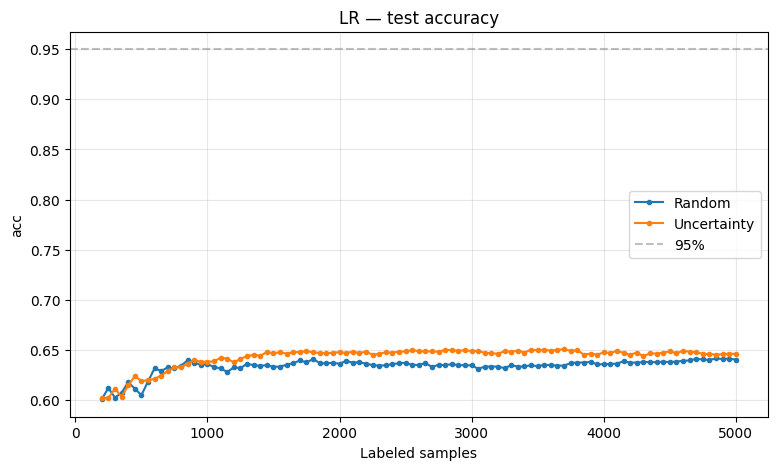

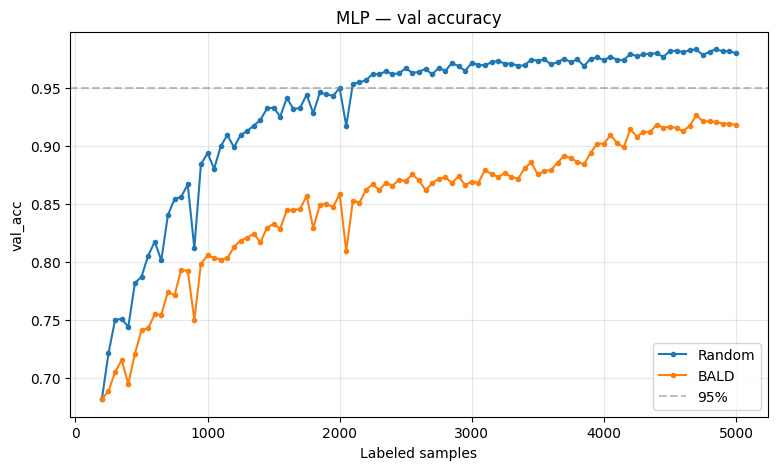

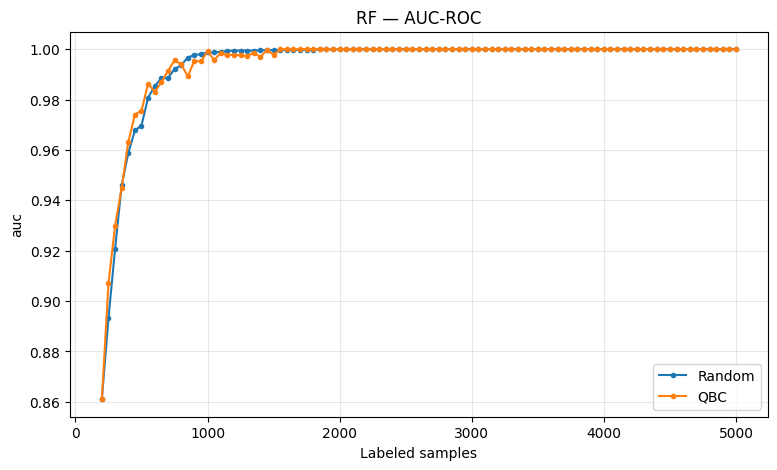

In [74]:
# sklearn models (Active_learning → keys "acc", "f1", "auc")
plot_learning_curves(history_LR_random, history_LR_uncert,
                     labels=["Random","Uncertainty"], metric="acc",
                     title="LR — test accuracy")

# MLP (deep_active_learning → keys "val_acc", "val_f1", "val_auc")
plot_learning_curves(history_MLP_random, history_MLP_bald,
                     labels=["Random","BALD"], metric="val_acc",
                     title="MLP — val accuracy")

# AUC curves
plot_learning_curves(history_RF_random, history_RF_qbc,
                     labels=["Random","QBC"], metric="auc",
                     title="RF — AUC-ROC")
